In [1]:
import numpy as np
import matplotlib.pyplot as plt
from geometry_class import Geometry
from parametrizations import Parameter
from visualization_fct import get_grid, eval_fct_on_grid
from dolfinx.fem import functionspace, Function
import pickle

In [8]:
filename = "./solutions/full_5min_icetempgradient.pkl"
with open(filename, "rb") as f:
    data_Annika = pickle.load(f)

nx = data_Annika["geometry"]["nx"]
nz = data_Annika["geometry"]["nz"]
geom = Geometry()
geom.make_from_dict(data_Annika["geometry"])
domain = geom.make_domain(nx, nz)
[P0, P1, P2, P3] = geom.corner_points
V = functionspace(domain, ("CG", 1))
hw = Function(V)
phi = Function(V)
T_i = Function(V)
T_w = Function(V)
p = Parameter(domain)

In [13]:
t_obs = 1
hw.x.array[:] = data_Annika["h_w"][t_obs]
phi.x.array[:] = data_Annika["phi"][t_obs]
T_i.x.array[:] = data_Annika["T_i"][t_obs]
T_w.x.array[:] = data_Annika["T_w"][t_obs]
grid, x_plot, z_plot = get_grid(P0, P1, P2, P3, nx, nz)
pressure_head = eval_fct_on_grid(grid, hw, domain).reshape((nz, nx))
porosity = eval_fct_on_grid(grid, phi, domain).reshape((nz, nx))
Ti = eval_fct_on_grid(grid, T_i, domain).reshape((nz, nx))
Tw = eval_fct_on_grid(grid, T_w, domain).reshape((nz, nx))

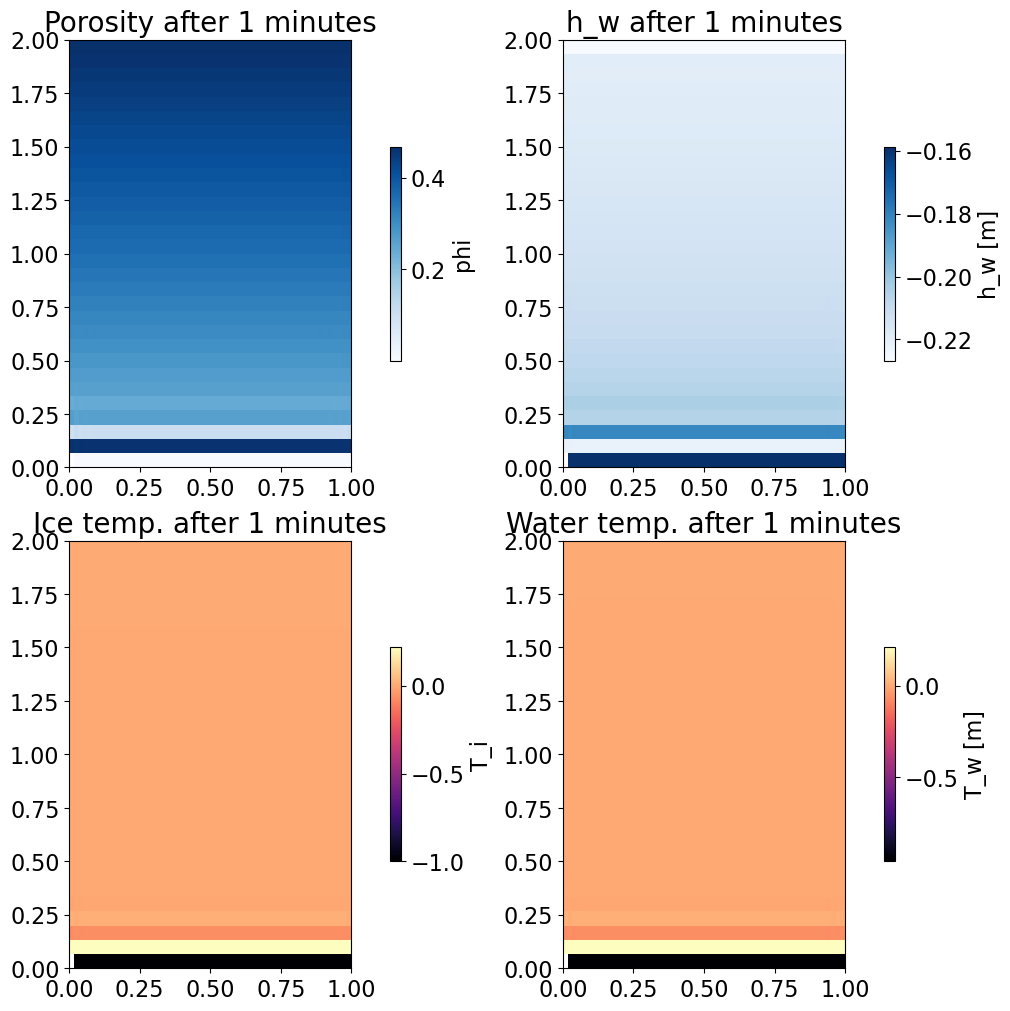

In [14]:
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(2,2, layout="constrained", figsize=(10,10))
pmsh1 = ax[0,0].pcolormesh(x_plot, z_plot, porosity, cmap="Blues")
ax[0,0].set_title(f"Porosity after {t_obs} minutes", fontsize=20)
cbar1 = fig.colorbar(pmsh1, ax=ax[0,0], shrink=0.5)
cbar1.set_label("phi")

pmsh2 = ax[0,1].pcolormesh(x_plot, z_plot, pressure_head, cmap="Blues")
ax[0,1].set_title(f"h_w after {t_obs} minutes", fontsize=20)
plt.xticks(fontsize=16)
cbar2 = fig.colorbar(pmsh2, ax=ax[0,1], shrink=0.5)
cbar2.set_label("h_w [m]")

pmsh3 = ax[1,0].pcolormesh(x_plot, z_plot, Ti, cmap="magma")
ax[1,0].set_title(f"Ice temp. after {t_obs} minutes", fontsize=20)
cbar1 = fig.colorbar(pmsh3, ax=ax[1,0], shrink=0.5)
cbar1.set_label("T_i")

pmsh4 = ax[1,1].pcolormesh(x_plot, z_plot, Tw, cmap="magma")
ax[1,1].set_title(f"Water temp. after {t_obs} minutes", fontsize=20)
plt.xticks(fontsize=16)
cbar2 = fig.colorbar(pmsh4, ax=ax[1,1], shrink=0.5)
cbar2.set_label("T_w [m]")

In [5]:
from dolfinx import mesh
Ks_calc1 = Ks[0,1]*100*60
Ks_calc2 = Ks[20,20]*100*60
print(f"calculated Ks from parametrization: {Ks_calc2} cm/min, {Ks_calc1} cm/min, direct Ks from snow type: {layer_params[1]['Ks']} cm/min, {layer_params[2]['Ks']} cm/min")

calculated Ks from parametrization: 2.439906115602676 cm/min, 8.104259662216483 cm/min, direct Ks from snow type: 4.764 cm/min, 5.298 cm/min


In [7]:
4.764/(100*60)

0.000794

2026-06-24 15:09:32.186 (  13.576s) [    7ED7F17A1600]vtkXOpenGLRenderWindow.:1458  WARN| bad X server connection. DISPLAY=


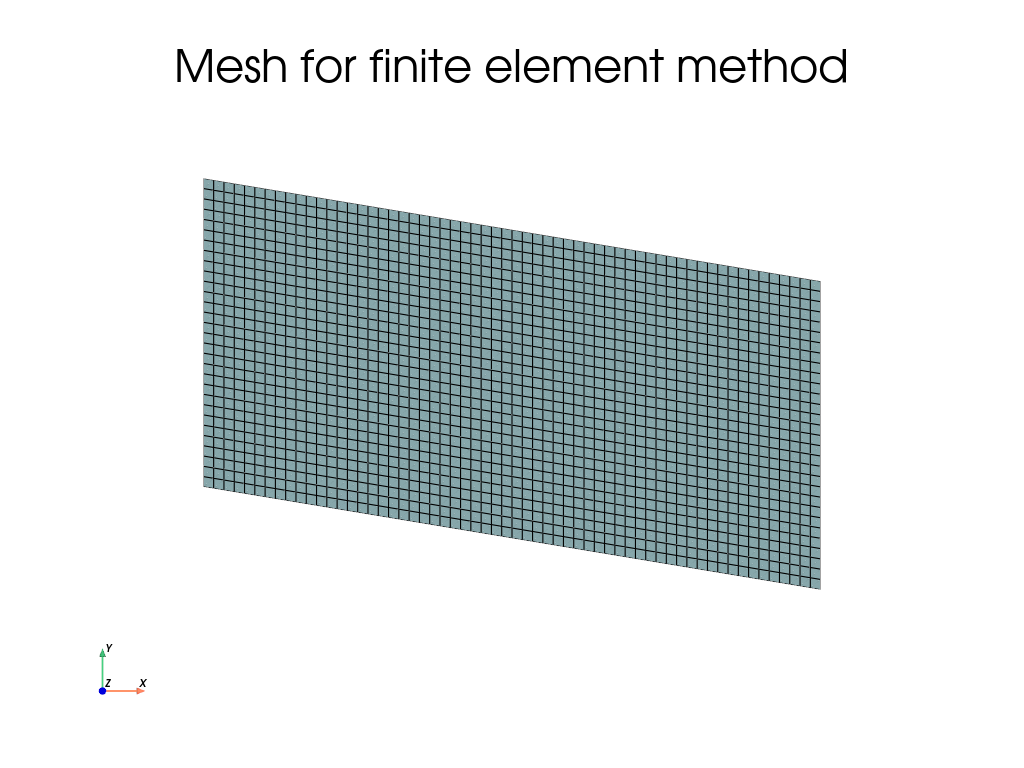

In [6]:
from visualization_fct import plot_mesh2
plot_mesh2(domain)

In [15]:
T_i = Function(V)
T_w = Function(V)
h = Function(V)
phi = Function(V)
phi.x.array[:] = 0.468
h.x.array[:] = 0.6
T_i.x.array[:] = -1
T_w.x.array[:] = 0
p.S_e_numerical(h)

array([1., 1., 1., ..., 1., 1., 1.], shape=(1891,))